---
## Phase 1 — Big Data Environment Setup and Data Acquisition

### 1.1 Install Arabic NLP libraries 

In [1]:
import sys, subprocess, os

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet",
                    "--break-system-packages", *pkgs], check=False)

# Install once; safe to re-run
_pip("pyarabic", "nltk", "datasets", "pyarrow")

import nltk
for resource in ["stopwords", "punkt", "punkt_tab"]:
    try:
        nltk.data.find(f"corpora/{resource}" if resource == "stopwords"
                       else f"tokenizers/{resource}")
    except LookupError:
        nltk.download(resource, quiet=True)

### 1.2 Imports and start Spark session

In [1]:
import re, json, time, glob, math, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import (HashingTF, IDF, VectorAssembler, StandardScaler)
from pyspark.ml.classification import (LogisticRegression, NaiveBayes,
                                       RandomForestClassifier,
                                       LogisticRegressionModel,
                                       NaiveBayesModel,
                                       RandomForestClassificationModel)
from pyspark.ml.evaluation import (MulticlassClassificationEvaluator,
                                   BinaryClassificationEvaluator)

# Arabic NLP libs
import pyarabic.araby as araby
from nltk.corpus import stopwords as nltk_stopwords

spark = (SparkSession.builder
         .appName("ArabicAIDetect_F011_F034")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .config("spark.sql.execution.arrow.pyspark.enabled", "true")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/10 17:33:01 WARN Utils: Your hostname, localhost.localdomain, resolves to a loopback address: 127.0.0.1; using 10.0.2.15 instead (on interface enp0s3)
26/05/10 17:33:01 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/10 17:33:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1


### 1.3 Project directory layout

In [3]:
import os

In [4]:
BASE_DIR  = os.path.abspath("./arabic_ai_detection_f011_f034")
RAW_DIR   = os.path.join(BASE_DIR, "data", "raw")
PROC_DIR  = os.path.join(BASE_DIR, "data", "processed")
MODEL_DIR = os.path.join(BASE_DIR, "models")
FIG_DIR   = os.path.join(BASE_DIR, "reports", "figures")
STREAM_IN  = os.path.join(BASE_DIR, "stream", "incoming")
STREAM_OUT = os.path.join(BASE_DIR, "stream", "predictions")
CHK_DIR    = os.path.join(BASE_DIR, "stream", "checkpoint")

for d in [RAW_DIR, PROC_DIR, MODEL_DIR, FIG_DIR, STREAM_IN, STREAM_OUT, CHK_DIR]:
    os.makedirs(d, exist_ok=True)
print("Project root:", BASE_DIR)

Project root: /home/aziz/Downloads/arabic_ai_detection_f011_f034


### 1.4 Download dataset from Hugging Face

In [9]:
import os
import pandas as pd
from datasets import load_dataset

RAW_DIR = os.path.join(BASE_DIR, "data", "raw")
os.makedirs(RAW_DIR, exist_ok=True)

HF_TOKEN = os.environ.get("HF_TOKEN", None)
if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)

dataset = load_dataset("KFUPM-JRCAI/arabic-generated-abstracts")

print("Dataset splits:", list(dataset.keys()))
for split_name, split_data in dataset.items():
    print(f"  {split_name}: {len(split_data):,} rows | columns: {split_data.column_names}")

def fetch_arabic_dataset():

    out_path = os.path.join(RAW_DIR, "arabic_abstracts_full.csv")

    if os.path.exists(out_path):
        print(f" [Cache] Dataset already exists locally: {out_path}")
        return out_path

    print(" [Converting] Saving Hugging Face dataset to local CSV for Spark...")

    first_split = list(dataset.keys())[0]
    df = dataset[first_split].to_pandas()

    df.to_csv(out_path, index=False, encoding='utf-8-sig')

    print(f" [Success] Final raw data path: {out_path}")
    return out_path

raw_data_path = fetch_arabic_dataset()

Dataset splits: ['by_polishing', 'from_title', 'from_title_and_content']
  by_polishing: 2,851 rows | columns: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract']
  from_title: 2,963 rows | columns: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract']
  from_title_and_content: 2,574 rows | columns: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract']
 [Converting] Saving Hugging Face dataset to local CSV for Spark...
 [Success] Final raw data path: /home/aziz/Downloads/arabic_ai_detection_f011_f034/data/raw/arabic_abstracts_full.csv


### 1.5 Reshape into long format `(text, label, model, source)`

In [12]:
def melt_to_text_label(df_pd, source_name):
    rows = []
    for _, r in df_pd.iterrows():
        if isinstance(r.get("original_abstract"), str) and r["original_abstract"].strip():
            rows.append((r["original_abstract"], 0, "human", source_name))
        for col in AI_COLS:
            v = r.get(col)
            if isinstance(v, str) and v.strip():
                rows.append((v, 1, col.replace("_generated_abstract",""), source_name))
    return pd.DataFrame(rows, columns=["text","label","model","source"])

frames = [melt_to_text_label(pd.read_csv(raw_data_path),"huggingface_data")]
long_pd = pd.concat(frames, ignore_index=True)
print("Total samples:", len(long_pd))
long_pd.head(3)

Total samples: 14255


,text,label,model,source
0,كثيرا ما ارتبطت المصادر التاريخية في الأندلس خ...,0,human,huggingface_data
1,يتناول هذا البحث موضوع التعليم بين النساء الأن...,1,allam,huggingface_data
2,تدرس هذه الدراسة دور المرأة في التعليم في الأن...,1,jais,huggingface_data


In [13]:
schema = T.StructType([
    T.StructField("text",   T.StringType(),  False),
    T.StructField("label",  T.IntegerType(), False),
    T.StructField("model",  T.StringType(),  False),
    T.StructField("source", T.StringType(),  False),
])
df = spark.createDataFrame(long_pd, schema=schema).cache()
print("Spark row count:", df.count())
df.printSchema()
df.groupBy("label").count().show()
df.groupBy("source","model").count().orderBy("source","model").show(truncate=False)

26/05/10 19:08:21 WARN TaskSetManager: Stage 0 contains a task of very large size (9741 KiB). The maximum recommended task size is 1000 KiB.
26/05/10 19:08:22 WARN TaskSetManager: Stage 1 contains a task of very large size (9741 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

Spark row count: 14255
root
 |-- text: string (nullable = false)
 |-- label: integer (nullable = false)
 |-- model: string (nullable = false)
 |-- source: string (nullable = false)



26/05/10 19:08:23 WARN TaskSetManager: Stage 4 contains a task of very large size (9741 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

+-----+-----+
|label|count|
+-----+-----+
|    1|11404|
|    0| 2851|
+-----+-----+



26/05/10 19:08:25 WARN TaskSetManager: Stage 7 contains a task of very large size (9741 KiB). The maximum recommended task size is 1000 KiB.


+----------------+------+-----+
|source          |model |count|
+----------------+------+-----+
|huggingface_data|allam |2851 |
|huggingface_data|human |2851 |
|huggingface_data|jais  |2851 |
|huggingface_data|llama |2851 |
|huggingface_data|openai|2851 |
+----------------+------+-----+



---
## Phase 2 — Distributed Preprocessing, Storage, EDA

### 2.1 Arabic preprocessing pipeline

Using **`pyarabic.araby`** for normalization (instead of hand-rolled regex) and
**`nltk.corpus.stopwords('arabic')`** for the stop-word list.

In [ ]:

AR_STOPWORDS = set(nltk_stopwords.words("arabic"))
print(f"NLTK Arabic stopwords loaded: {len(AR_STOPWORDS)} words")
print("Sample:", list(AR_STOPWORDS)[:10])
SW_BC = spark.sparkContext.broadcast(AR_STOPWORDS)

NLTK Arabic stopwords loaded: 701 words
Sample: ['تانِ', 'سبع', 'تَيْنِ', 'ذات', 'بئس', 'لستم', 'كلَّا', 'اخلولق', 'أُفٍّ', 'سبحان']


In [ ]:
def _normalize_arabic(text: str):
    """Use pyarabic.araby to: strip diacritics & tatweel, unify hamza/alef/yaa/taa."""
    if text is None:
        return None
    t = araby.strip_tashkeel(text)
    t = araby.strip_tatweel(t)
    t = araby.normalize_hamza(t)
    t = araby.normalize_alef(t)
    t = araby.normalize_ligature(t)
   
    t = re.sub(r"[^\u0600-\u06FF\sA-Za-z0-9\.\,\!\?\:\;\n]", " ", t)
    t = re.sub(r"[ \t]+", " ", t).strip()
    return t

def _tokenize(text: str):
    """Split on whitespace via pyarabic, drop short tokens and Arabic stopwords."""
    if not text:
        return []
    toks = araby.tokenize(text)
    sw = SW_BC.value
    return [w for w in toks if len(w) > 1 and w not in sw and not w.isspace()]

normalize_udf = F.udf(_normalize_arabic, T.StringType())
tokenize_udf  = F.udf(_tokenize,         T.ArrayType(T.StringType()))


df_clean = (df
    .withColumn("clean_text_columns", normalize_udf(F.col("text")))
    .withColumn("tokens",             tokenize_udf(F.col("clean_text_columns")))
    .withColumn("n_tokens",           F.size("tokens"))
    .filter(F.col("n_tokens") >= 5)).cache()

print("Rows after cleaning:", df_clean.count())
df_clean.select("label","n_tokens","clean_text_columns").show(3, truncate=80)

/home/aziz/.local/lib/python3.12/site-packages/pyspark/sql/udf.py:134: UserWarning: Cannot infer the eval type from type hints. 
  warnings.warn("Cannot infer the eval type from type hints. ", UserWarning)
26/05/10 19:08:30 WARN TaskSetManager: Stage 10 contains a task of very large size (9741 KiB). The maximum recommended task size is 1000 KiB.
26/05/10 19:08:36 WARN TaskSetManager: Stage 11 contains a task of very large size (9741 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

Rows after cleaning: 14255
+-----+--------+--------------------------------------------------------------------------------+
|label|n_tokens|                                                              clean_text_columns|
+-----+--------+--------------------------------------------------------------------------------+
|    0|      95|كثيرا ما ارتبطت المصادر التاريخية في الءندلس خاصة منها كتب التراجم والفهرسات ...|
|    1|      62|يتناول هذا البحث موضوع التعليم بين النساء الءندلسيات من خلال دراسة المصادر ال...|
|    1|      52|تدرس هذه الدراسة دور المرءة في التعليم في الءندلس من خلال مصادر تاريخية مثل ك...|
+-----+--------+--------------------------------------------------------------------------------+
only showing top 3 rows


26/05/10 19:08:37 WARN TaskSetManager: Stage 14 contains a task of very large size (9741 KiB). The maximum recommended task size is 1000 KiB.


### 2.2 Persist as Parquet (compressed columnar store)

In [16]:
parquet_path = os.path.join(PROC_DIR, "abstracts.parquet")
(df_clean.select("text","clean_text_columns","tokens","n_tokens",
                 "label","model","source")
         .write.mode("overwrite").parquet(parquet_path))

df_proc = spark.read.parquet(parquet_path).cache()
print("Reloaded rows:", df_proc.count())

26/05/10 19:08:49 WARN TaskSetManager: Stage 15 contains a task of very large size (9741 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

Reloaded rows: 14255


### 2.3 Exploratory Data Analysis

**Class balance**

   label  count   pct
0      1  11404  80.0
1      0   2851  20.0


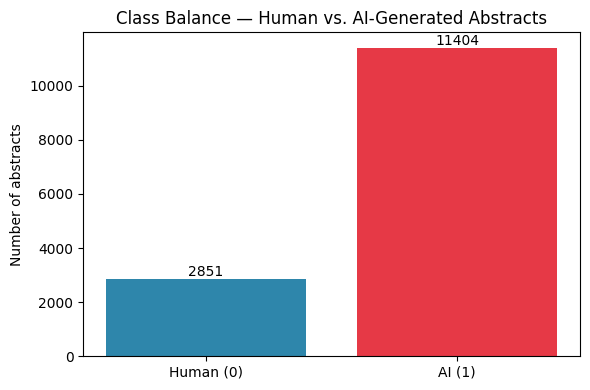

In [17]:
label_counts = (df_proc.groupBy("label").count()
                  .withColumn("pct", F.round(F.col("count")/df_proc.count()*100,2))
                  .toPandas())
print(label_counts)

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(["Human (0)","AI (1)"], label_counts.sort_values("label")["count"],
       color=["#2E86AB","#E63946"])
ax.set_title("Class Balance — Human vs. AI-Generated Abstracts")
ax.set_ylabel("Number of abstracts")
for i,v in enumerate(label_counts.sort_values("label")["count"]):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,"class_balance.png"), dpi=120)
plt.show()

**Per-model distribution**

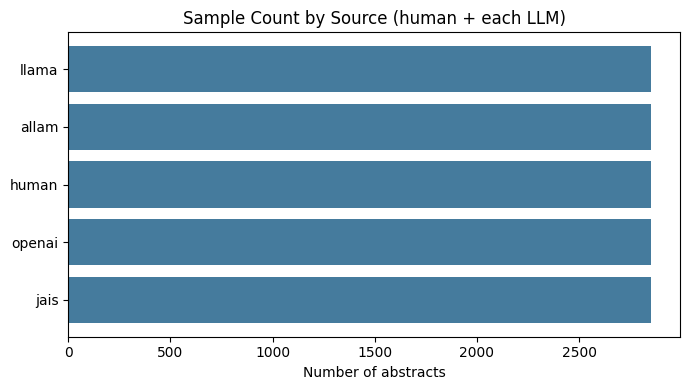

In [18]:
model_pd = df_proc.groupBy("model").count().toPandas().sort_values("count")
fig, ax = plt.subplots(figsize=(7,4))
ax.barh(model_pd["model"], model_pd["count"], color="#457B9D")
ax.set_title("Sample Count by Source (human + each LLM)")
ax.set_xlabel("Number of abstracts")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,"per_model_counts.png"), dpi=120)
plt.show()

**Token-length distribution per class**

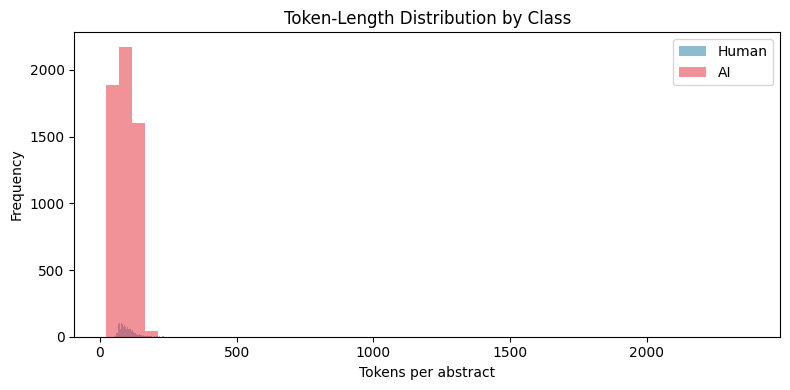

In [19]:
len_pd = df_proc.select("label","n_tokens").sample(False, 0.5, seed=7).toPandas()
fig, ax = plt.subplots(figsize=(8,4))
for lbl, color, name in [(0,"#2E86AB","Human"),(1,"#E63946","AI")]:
    ax.hist(len_pd[len_pd.label==lbl]["n_tokens"], bins=50, alpha=0.55,
            label=name, color=color)
ax.set_xlabel("Tokens per abstract"); ax.set_ylabel("Frequency")
ax.set_title("Token-Length Distribution by Class"); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,"token_length_dist.png"), dpi=120)
plt.show()

**Top unigrams**

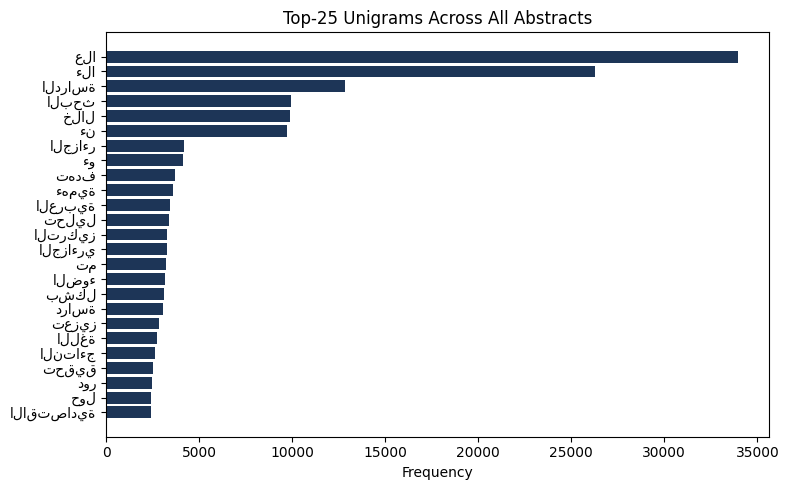

In [20]:
top_unigrams = (df_proc
    .select(F.explode("tokens").alias("w"))
    .groupBy("w").count().orderBy(F.desc("count"))
    .limit(25).toPandas())

fig, ax = plt.subplots(figsize=(8,5))
ax.barh(top_unigrams["w"][::-1], top_unigrams["count"][::-1], color="#1D3557")
ax.set_title("Top-25 Unigrams Across All Abstracts")
ax.set_xlabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,"top_unigrams.png"), dpi=120)
plt.show()

**Bigram frequencies**

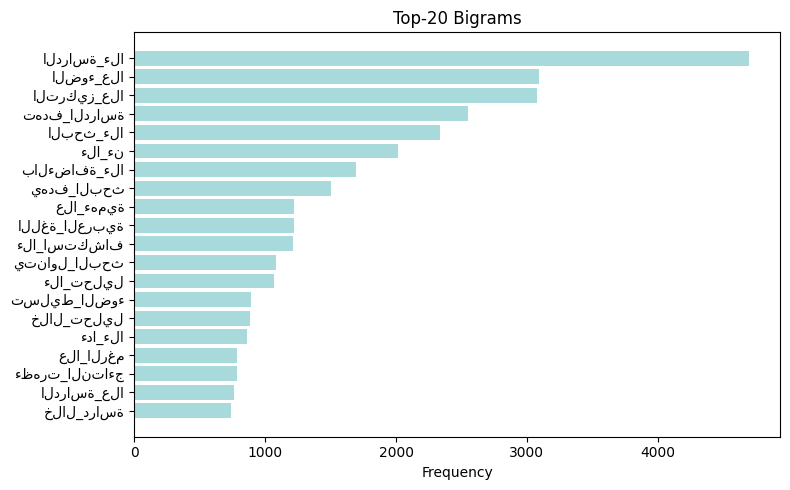

In [21]:
def _to_bigrams(toks):
    return [f"{a}_{b}" for a,b in zip(toks, toks[1:])]
bigrams_udf = F.udf(_to_bigrams, T.ArrayType(T.StringType()))

top_bigrams = (df_proc
    .withColumn("bg", bigrams_udf("tokens"))
    .select(F.explode("bg").alias("b"))
    .groupBy("b").count().orderBy(F.desc("count"))
    .limit(20).toPandas())

fig, ax = plt.subplots(figsize=(8,5))
ax.barh(top_bigrams["b"][::-1], top_bigrams["count"][::-1], color="#A8DADC")
ax.set_title("Top-20 Bigrams")
ax.set_xlabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,"top_bigrams.png"), dpi=120)
plt.show()

**Vocabulary richness (TTR) per class**

   label   avg_TTR
1      0  0.842426
0      1  0.824120


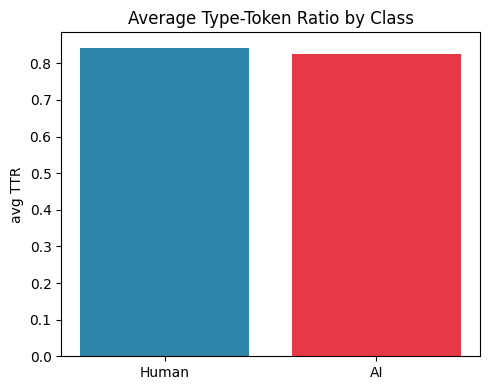

In [22]:
ttr_pd = (df_proc
    .withColumn("uniq", F.size(F.array_distinct("tokens")))
    .withColumn("ttr",  F.col("uniq")/F.col("n_tokens"))
    .groupBy("label").agg(F.avg("ttr").alias("avg_TTR"))
    .toPandas().sort_values("label"))
print(ttr_pd)

fig, ax = plt.subplots(figsize=(5,4))
ax.bar(["Human","AI"], ttr_pd["avg_TTR"], color=["#2E86AB","#E63946"])
ax.set_title("Average Type-Token Ratio by Class")
ax.set_ylabel("avg TTR")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,"ttr_by_class.png"), dpi=120)
plt.show()

---
## Phase 3 — Scalable Feature Engineering & Batch Modeling

### 3.1 Stylometric features f011 and f034

Following the assigned naming convention:
`feature_name = f'{clean_text_columns}_f0XX_<descriptive>'`

In [ ]:

clean_text_columns = "clean_text_columns"
feature_name_f011  = f'{clean_text_columns}_f011_num_long_words_over_N'
feature_name_f034  = f'{clean_text_columns}_f034_total_lines'

print("Feature column names:")
print(" ", feature_name_f011)
print(" ", feature_name_f034)

Feature column names:
  clean_text_columns_f011_num_long_words_over_N
  clean_text_columns_f034_total_lines


In [ ]:
def _long_word_ratio(words, min_length=6):
    """f011 — ratio of long words (length > min_length) to total word count N."""
    total_words = len(words)
    if total_words == 0:
        return 0.0
    long_words_count = sum(1 for w in words if len(w) > min_length)
    return float(long_words_count) / total_words


def _total_lines(raw_text):
    """f034 — total physical lines in the original (un-normalized) text."""
    if not raw_text:
        return 0
    return raw_text.count("\n") + 1



f011_udf = F.udf(lambda ws: _long_word_ratio(ws),  T.DoubleType())
f034_udf = F.udf(lambda txt: _total_lines(txt),    T.IntegerType())

df_feat = (df_proc
   .withColumn(feature_name_f011, f011_udf(F.col("tokens")))
   .withColumn(feature_name_f034, f034_udf(F.col("text")))).cache()

df_feat.select("label", "n_tokens",
               feature_name_f011, feature_name_f034).show(5)

[Stage 41:>                                                         (0 + 1) / 1]

+-----+--------+---------------------------------------------+-----------------------------------+
|label|n_tokens|clean_text_columns_f011_num_long_words_over_N|clean_text_columns_f034_total_lines|
+-----+--------+---------------------------------------------+-----------------------------------+
|    0|      95|                           0.3473684210526316|                                  1|
|    1|      62|                           0.3548387096774194|                                  1|
|    1|      52|                           0.4230769230769231|                                  1|
|    1|      81|                           0.3333333333333333|                                  1|
|    1|     137|                          0.32116788321167883|                                  1|
+-----+--------+---------------------------------------------+-----------------------------------+
only showing top 5 rows


**Sanity-check the helpers on a pandas slice (matches the snippet you supplied)**

In [ ]:
sample_pd = df_feat.select("tokens","text",
                              feature_name_f011, feature_name_f034
                             ).limit(50).toPandas()


sample_pd["pandas_f011"] = sample_pd["tokens"].apply(lambda ws: _long_word_ratio(ws))
sample_pd["pandas_f034"] = sample_pd["text"].apply(lambda t: _total_lines(t))

ok_011 = np.allclose(sample_pd[feature_name_f011], sample_pd["pandas_f011"])
ok_034 = (sample_pd[feature_name_f034] == sample_pd["pandas_f034"]).all()
print("f011 Spark==pandas:", ok_011)
print("f034 Spark==pandas:", ok_034)

f011 Spark==pandas: True
f034 Spark==pandas: True


**EDA on the engineered features**

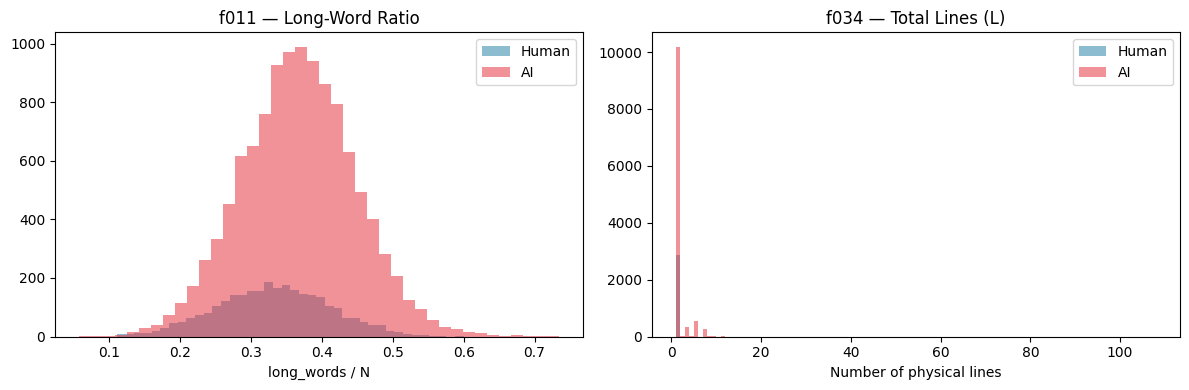

      clean_text_columns_f011_num_long_words_over_N                       \
                                              count   mean    std    min   
label                                                                      
0                                            2851.0  0.332  0.079  0.111   
1                                           11404.0  0.367  0.080  0.057   

                                  clean_text_columns_f034_total_lines         \
         25%    50%    75%    max                               count   mean   
label                                                                          
0      0.278  0.333  0.388  0.600                              2851.0  1.000   
1      0.313  0.366  0.420  0.735                             11404.0  1.439   

                                         
         std  min  25%  50%  75%    max  
label                                    
0      0.000  1.0  1.0  1.0  1.0    1.0  
1      1.685  1.0  1.0  1.0  1.0  107.0  


In [26]:
feat_pd = df_feat.select("label", feature_name_f011,
                               feature_name_f034).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12,4))
for lbl, color, name in [(0,"#2E86AB","Human"),(1,"#E63946","AI")]:
    axes[0].hist(feat_pd[feat_pd.label==lbl][feature_name_f011],
                 bins=40, alpha=0.55, label=name, color=color)
axes[0].set_title("f011 — Long-Word Ratio")
axes[0].set_xlabel("long_words / N"); axes[0].legend()

max_lines = int(feat_pd[feature_name_f034].max())
for lbl, color, name in [(0,"#2E86AB","Human"),(1,"#E63946","AI")]:
    axes[1].hist(feat_pd[feat_pd.label==lbl][feature_name_f034],
                 bins=range(1, max_lines+2),
                 alpha=0.55, label=name, color=color)
axes[1].set_title("f034 — Total Lines (L)")
axes[1].set_xlabel("Number of physical lines"); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,"features_f011_f034_dist.png"), dpi=120)
plt.show()

print(feat_pd.groupby("label").describe().round(3))

### 3.2 Advanced features — TF-IDF (Spark MLlib)

In [27]:
hashing = HashingTF(inputCol="tokens", outputCol="tf", numFeatures=4096)
idf     = IDF(inputCol="tf", outputCol="tfidf")

stylo_assembler = VectorAssembler(
    inputCols=[feature_name_f011, feature_name_f034, "n_tokens"],
    outputCol="stylo_raw")
scaler = StandardScaler(inputCol="stylo_raw", outputCol="stylo",
                        withMean=False, withStd=True)
final_assembler = VectorAssembler(inputCols=["tfidf","stylo"], outputCol="features")

prep_pipeline = Pipeline(stages=[hashing, idf, stylo_assembler, scaler,
                                 final_assembler])
prep_model    = prep_pipeline.fit(df_feat)
df_ready      = prep_model.transform(df_feat).select("features","label").cache()
df_ready.show(3, truncate=60)

+------------------------------------------------------------+-----+
|                                                    features|label|
+------------------------------------------------------------+-----+
|(4099,[32,44,89,153,186,316,327,345,383,395,522,614,619,6...|    0|
|(4099,[44,153,311,392,396,427,522,622,687,693,866,1309,14...|    1|
|(4099,[153,210,218,337,383,543,619,952,1069,1094,1220,143...|    1|
+------------------------------------------------------------+-----+
only showing top 3 rows


### 3.3 Train / Validation / Test split (70 / 15 / 15)

In [28]:
train_df, val_df, test_df = df_ready.randomSplit([0.7, 0.15, 0.15], seed=42)
print(f"train={train_df.count()}  val={val_df.count()}  test={test_df.count()}")

train=10130  val=2037  test=2088


### 3.4 + 3.5 Models — baseline + two advanced classifiers

In [29]:
def evaluate(model, data, name):
    preds = model.transform(data)
    acc = MulticlassClassificationEvaluator(metricName="accuracy").evaluate(preds)
    f1  = MulticlassClassificationEvaluator(metricName="f1").evaluate(preds)
    auc = BinaryClassificationEvaluator(metricName="areaUnderROC").evaluate(preds)
    print(f"{name:<22s}  acc={acc:.4f}  f1={f1:.4f}  AUC={auc:.4f}")
    return {"model":name, "acc":acc, "f1":f1, "auc":auc, "preds":preds}

results = {}

t0 = time.time()
lr_model = LogisticRegression(maxIter=30, regParam=0.01).fit(train_df)
results["LogReg"] = evaluate(lr_model, val_df, "LogReg (val)")
results["LogReg"]["train_time"] = time.time() - t0

t0 = time.time()
nb_model = NaiveBayes(smoothing=1.0, modelType="multinomial").fit(train_df)
results["NaiveBayes"] = evaluate(nb_model, val_df, "NaiveBayes (val)")
results["NaiveBayes"]["train_time"] = time.time() - t0

t0 = time.time()
rf_model = RandomForestClassifier(numTrees=60, maxDepth=10, seed=42).fit(train_df)
results["RandomForest"] = evaluate(rf_model, val_df, "RandomForest (val)")
results["RandomForest"]["train_time"] = time.time() - t0

26/05/10 19:11:22 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


LogReg (val)            acc=0.9435  f1=0.9424  AUC=0.9786
NaiveBayes (val)        acc=0.8949  f1=0.9009  AUC=0.6229


26/05/10 19:11:39 WARN DAGScheduler: Broadcasting large task binary with size 1069.3 KiB
26/05/10 19:11:40 WARN DAGScheduler: Broadcasting large task binary with size 1268.5 KiB
26/05/10 19:11:41 WARN DAGScheduler: Broadcasting large task binary with size 1509.3 KiB
26/05/10 19:11:41 WARN DAGScheduler: Broadcasting large task binary with size 1776.4 KiB
26/05/10 19:11:42 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
26/05/10 19:11:43 WARN DAGScheduler: Broadcasting large task binary with size 1359.9 KiB
26/05/10 19:11:44 WARN DAGScheduler: Broadcasting large task binary with size 1359.9 KiB
26/05/10 19:11:44 WARN DAGScheduler: Broadcasting large task binary with size 1347.9 KiB


RandomForest (val)      acc=0.8130  f1=0.7310  AUC=0.9706


**Final evaluation on the held-out test set + confusion matrix**

Best on validation: LogReg
LogReg (TEST)           acc=0.9377  f1=0.9359  AUC=0.9767

Confusion Matrix:
 prediction  0.0   1.0
label                
0           339    96
1            34  1619


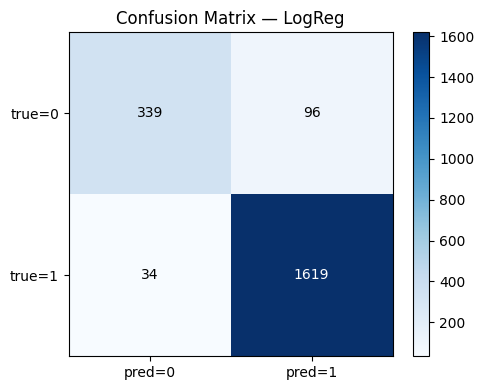

In [30]:
best_name  = max(results, key=lambda k: results[k]["f1"])
best_model = {"LogReg":lr_model, "NaiveBayes":nb_model,
              "RandomForest":rf_model}[best_name]
print("Best on validation:", best_name)

test_eval = evaluate(best_model, test_df, f"{best_name} (TEST)")

cm = (test_eval["preds"]
      .groupBy("label","prediction").count().toPandas()
      .pivot(index="label", columns="prediction", values="count")
      .fillna(0).astype(int))
print("\nConfusion Matrix:\n", cm)

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm.values, cmap="Blues")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["pred=0","pred=1"]); ax.set_yticklabels(["true=0","true=1"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm.values[i,j], ha="center", va="center",
                color="white" if cm.values[i,j] > cm.values.max()/2 else "black")
ax.set_title(f"Confusion Matrix — {best_name}")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,"confusion_matrix.png"), dpi=120)
plt.show()

**Persist the winning pipeline + classifier**

In [31]:
prep_path = os.path.join(MODEL_DIR, "prep_pipeline")
clf_path  = os.path.join(MODEL_DIR, f"clf_{best_name}")
shutil.rmtree(prep_path, ignore_errors=True)
shutil.rmtree(clf_path,  ignore_errors=True)
prep_model.write().overwrite().save(prep_path)
best_model.write().overwrite().save(clf_path)
print("Saved →", prep_path, "and", clf_path)

Saved → /home/aziz/Downloads/arabic_ai_detection_f011_f034/models/prep_pipeline and /home/aziz/Downloads/arabic_ai_detection_f011_f034/models/clf_LogReg


---
## Phase 4 — Stream Processing & Comprehensive Evaluation

### 4.1 File-based stream simulation (Kafka substitute on CentOS)

In [ ]:

reload_clf = {
    "LogReg":      LogisticRegressionModel,
    "NaiveBayes":  NaiveBayesModel,
    "RandomForest":RandomForestClassificationModel,
}[best_name].load(clf_path)
reload_prep = PipelineModel.load(prep_path)
print("Pipeline + classifier reloaded for streaming.")

Pipeline + classifier reloaded for streaming.


**Producer — drop a few JSON files into the incoming folder**

In [33]:
sample_pd = df.sample(False, 0.005, seed=11).limit(20).toPandas()
for fn in glob.glob(os.path.join(STREAM_IN,"*.json")):
    os.remove(fn)

for i, row in sample_pd.iterrows():
    rec = {"text": row["text"], "label": int(row["label"])}
    with open(os.path.join(STREAM_IN, f"abstract_{i:03d}.json"),
              "w", encoding="utf-8") as f:
        json.dump(rec, f, ensure_ascii=False)
print(f"Wrote {len(sample_pd)} JSON files → {STREAM_IN}")

Wrote 20 JSON files → /home/aziz/Downloads/arabic_ai_detection_f011_f034/stream/incoming


26/05/10 19:13:36 WARN TaskSetManager: Stage 248 contains a task of very large size (9741 KiB). The maximum recommended task size is 1000 KiB.


**4.2 Spark Structured Streaming consumer**

In [ ]:
stream_schema = T.StructType([
    T.StructField("text",  T.StringType()),
    T.StructField("label", T.IntegerType()),
])

stream_in = (spark.readStream
             .schema(stream_schema)
             .option("maxFilesPerTrigger", 5)
             .json(STREAM_IN))


stream_clean = (stream_in
   .withColumn("clean_text_columns", normalize_udf("text"))
   .withColumn("tokens",             tokenize_udf("clean_text_columns"))
   .withColumn("n_tokens",           F.size("tokens"))
   .filter(F.col("n_tokens") >= 5)
   .withColumn(feature_name_f011, f011_udf(F.col("tokens")))
   .withColumn(feature_name_f034, f034_udf(F.col("text"))))

stream_features = reload_prep.transform(stream_clean)
stream_preds    = (reload_clf.transform(stream_features)
                    .select("text","label","prediction","probability"))

q = (stream_preds.writeStream
       .outputMode("append")
       .format("json")
       .option("path", STREAM_OUT)
       .option("checkpointLocation", CHK_DIR)
       .trigger(processingTime="3 seconds")
       .start())

print("Streaming query started.")
q.awaitTermination(20)
q.stop()
print("Streaming query stopped.")

26/05/10 19:13:46 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


Streaming query started.


Streaming query stopped.


26/05/10 19:14:06 WARN DAGScheduler: Failed to cancel job group 3e8137b4-f9b7-42ae-a211-3d5484a78e1d. Cannot find active jobs for it.
26/05/10 19:14:06 WARN DAGScheduler: Failed to cancel job group 3e8137b4-f9b7-42ae-a211-3d5484a78e1d. Cannot find active jobs for it.


**Inspect the streaming output**

In [35]:
pred_files = glob.glob(os.path.join(STREAM_OUT, "*.json"))
print(f"Output files written: {len(pred_files)}")

if pred_files:
    s_df = spark.read.json(pred_files)
    s_df.select("text","label","prediction").show(5, truncate=60)
    pdf = s_df.select("label","prediction").toPandas()
    print(f"\nStreaming accuracy on simulated batch: "
          f"{(pdf.label == pdf.prediction).mean():.4f}")

Output files written: 8
+------------------------------------------------------------+-----+----------+
|                                                        text|label|prediction|
+------------------------------------------------------------+-----+----------+
|يتناول هذا البحث تحديات الأداء اللغوي في المجتمع العربي م...|    1|       1.0|
|في هذا البحث نركز على تحليل اللغة الشعرية ضمن إطار الشعر ...|    1|       1.0|
|العلوم الإنسانية شهدت تطورات بارزة منذ نشأتها، خاصة في مو...|    1|       1.0|
|تهدف هذه الدراسة إلى استكشاف المحتوى الرقمي المتعلق بالشي...|    1|       1.0|
|جامعة عبد الحميد بن باديس – مستغانم ينظر النحو الوظيفي إل...|    0|       0.0|
+------------------------------------------------------------+-----+----------+
only showing top 5 rows

Streaming accuracy on simulated batch: 1.0000


### 4.4 Scalability micro-benchmark

   partitions  seconds
0           2    0.389
1           4    0.150
2           8    0.148


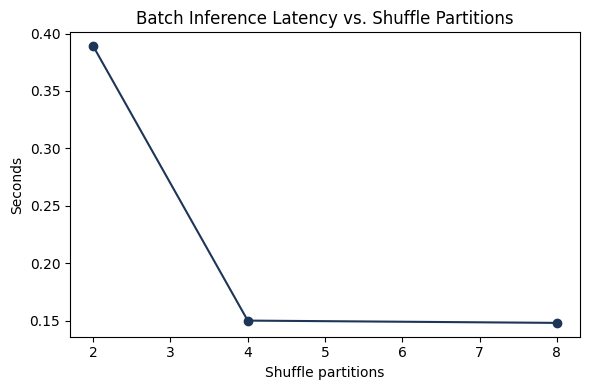

In [36]:
bench_rows = []
for n_part in [2, 4, 8]:
    spark.conf.set("spark.sql.shuffle.partitions", n_part)
    t0 = time.time()
    _ = best_model.transform(test_df).count()
    bench_rows.append((n_part, round(time.time()-t0, 3)))

bench_df = pd.DataFrame(bench_rows, columns=["partitions","seconds"])
print(bench_df)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(bench_df["partitions"], bench_df["seconds"], marker="o", color="#1D3557")
ax.set_title("Batch Inference Latency vs. Shuffle Partitions")
ax.set_xlabel("Shuffle partitions"); ax.set_ylabel("Seconds")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,"scalability_bench.png"), dpi=120)
plt.show()

---
## Phase 5 — Analysis, Interpretation & Reporting

In [37]:
summary = pd.DataFrame([
    {"model":k, "val_acc":round(v["acc"],4), "val_f1":round(v["f1"],4),
     "val_auc":round(v["auc"],4), "train_sec":round(v.get("train_time",0),2)}
    for k,v in results.items()
])
print(summary.sort_values("val_f1", ascending=False).to_string(index=False))

       model  val_acc  val_f1  val_auc  train_sec
      LogReg   0.9435  0.9424   0.9786       8.75
  NaiveBayes   0.8949  0.9009   0.6229       2.15
RandomForest   0.8130  0.7310   0.9706      13.19


**Feature importance — Random Forest (interpretable view of f011 / f034)**

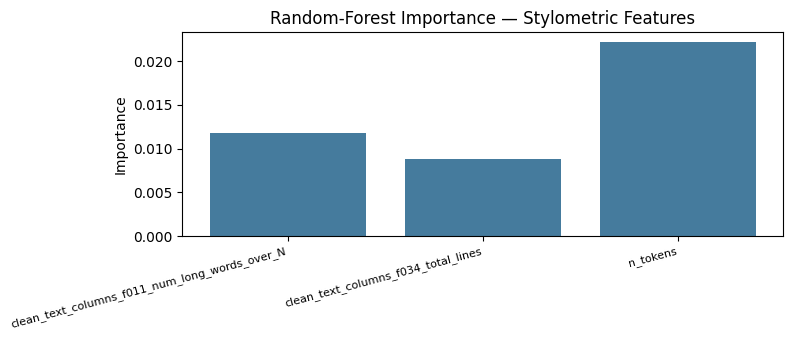

{'clean_text_columns_f011_num_long_words_over_N': 0.01183, 'clean_text_columns_f034_total_lines': 0.00881, 'n_tokens': 0.02218}


In [ ]:
if isinstance(rf_model, RandomForestClassificationModel):
    importances = rf_model.featureImportances.toArray()
  
    stylo_imp = importances[-3:]
    labels = [feature_name_f011, feature_name_f034, "n_tokens"]
    fig, ax = plt.subplots(figsize=(8,3.5))
    ax.bar(range(len(labels)), stylo_imp, color="#457B9D")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=8)
    ax.set_title("Random-Forest Importance — Stylometric Features")
    ax.set_ylabel("Importance")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR,"feature_importance_stylo.png"), dpi=120)
    plt.show()
    print(dict(zip(labels, [round(float(x),5) for x in stylo_imp])))

In [39]:
spark.stop()
print("Spark session closed. Artifacts under:", BASE_DIR)

Spark session closed. Artifacts under: /home/aziz/Downloads/arabic_ai_detection_f011_f034
